# House Price Prediction - Decision Tree Regressor

**Dataset:** Kaggle House Prices Dataset
**Link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data
**Algorithm:** Decision Tree Regressor
**Metrics:** MAE, RMSE, R2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv("../../data/train.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overa

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


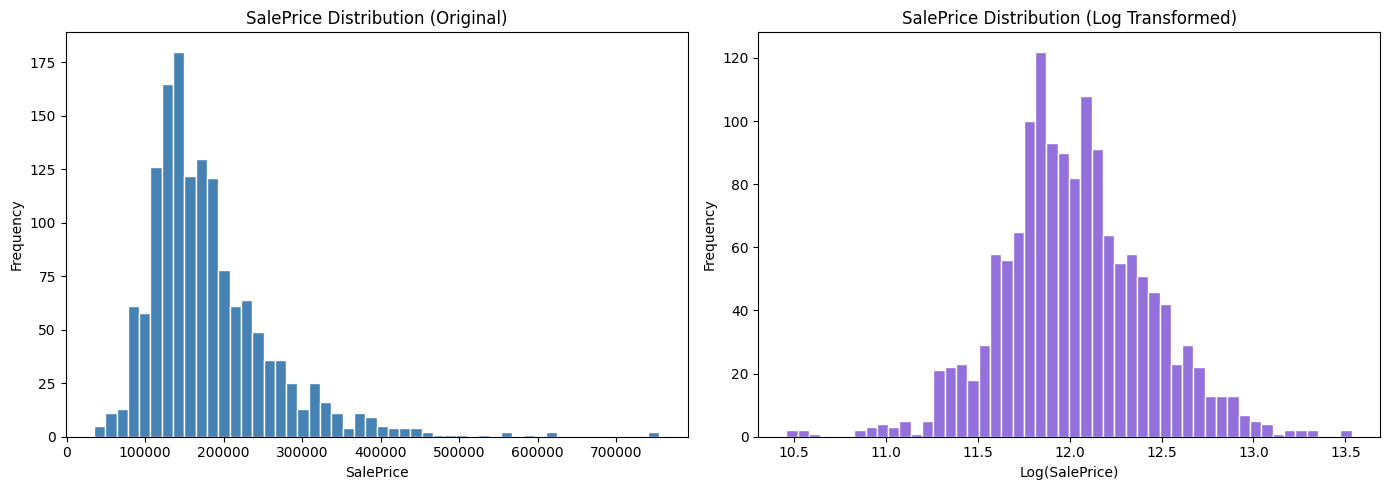

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='mediumpurple', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dt_saleprice_distribution.png', dpi=150)
plt.show()

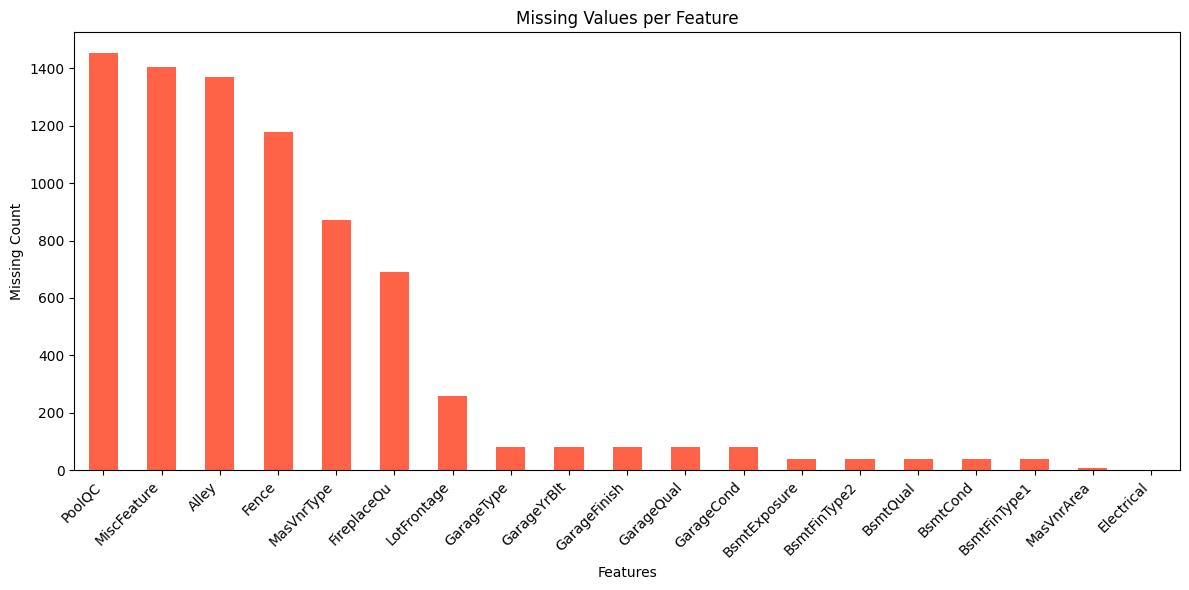

Total features with missing values: 19


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Feature')
plt.xlabel('Features')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('dt_missing_values.png', dpi=150)
plt.show()

print(f"Total features with missing values: {len(missing)}")

## 3. Data Preprocessing

In [7]:
# Drop ID column - not useful for prediction
df.drop('Id', axis=1, inplace=True)

# Log-transform target to reduce skewness
df['SalePrice'] = np.log1p(df['SalePrice'])

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# --- Handle Missing Values ---

# Categorical: fill with 'None' (feature simply absent)
cat_cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_cols_none:
    if col in X.columns:
        X[col] = X[col].fillna('None')

# Categorical: fill with most frequent value
cat_cols_mode = ['Electrical', 'MSZoning', 'KitchenQual', 'Exterior1st',
                 'Exterior2nd', 'Functional', 'SaleType']
for col in cat_cols_mode:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

# Numeric: fill with 0 (no feature present)
num_cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_cols_zero:
    if col in X.columns:
        X[col] = X[col].fillna(0)

# LotFrontage: fill with neighborhood median
X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values after cleaning: 0


## 4. Feature Engineering

In [8]:
# Same new features as teammates for consistency
X['TotalSF']   = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
X['TotalBath'] = (X['FullBath'] + 0.5 * X['HalfBath'] +
                  X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath'])
X['HouseAge']  = X['YrSold'] - X['YearBuilt']
X['RemodAge']  = X['YrSold'] - X['YearRemodAdd']

print("New features added: TotalSF, TotalBath, HouseAge, RemodAge")
print("Updated Feature Matrix Shape:", X.shape)

# Encode categorical columns
label_encoders = {}
cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(cat_features)} categorical features")
print("Final Feature Matrix Shape:", X.shape)

New features added: TotalSF, TotalBath, HouseAge, RemodAge
Updated Feature Matrix Shape: (1460, 83)
Encoded 43 categorical features
Final Feature Matrix Shape: (1460, 83)


## 5. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (1168, 83)
Test set size:     (292, 83)


## 6. Background & Justification: Decision Tree

A **Decision Tree** splits data into branches based on feature thresholds,
creating a tree of if/else rules that leads to a prediction at each leaf node.

### Why Decision Tree for House Price Prediction?
- Easy to understand and visualise - you can literally see the decisions
- Handles both numeric and categorical features naturally
- No need for feature scaling (unlike SVR)
- Captures non-linear relationships between features and price

### Key Hyperparameters

| Parameter | Description |
|---|---|
| max_depth | How deep the tree grows - deeper = more complex |
| min_samples_split | Minimum samples needed to split a node |
| min_samples_leaf | Minimum samples required at a leaf node |
| max_features | Number of features considered at each split |

### Known Limitation
A single Decision Tree tends to **overfit** - it memorises training data.
This is exactly why Random Forest (used by a teammate) wraps many trees
together to fix this problem.

## 7. Train the Decision Tree Model

In [10]:
# Baseline Decision Tree with no restrictions (will likely overfit)
dt_baseline = DecisionTreeRegressor(random_state=42)
dt_baseline.fit(X_train, y_train)

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [11]:
param_grid = {
    'max_depth'        : [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE (log scale):", -grid_search.best_score_)

best_dt = grid_search.best_estimator_
print("Tuned Decision Tree ready.")

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE (log scale): 0.18587003803094554
Tuned Decision Tree ready.


## 8. Evaluation & Results

In [12]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """Evaluate a regression model, converting predictions back from log scale."""
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    # Reverse the log transform to get real dollar values
    y_tr_orig      = np.expm1(y_tr)
    y_te_orig      = np.expm1(y_te)
    y_tr_pred_orig = np.expm1(y_tr_pred)
    y_te_pred_orig = np.expm1(y_te_pred)

    print(f'\n========== {model_name} ==========')
    print(f'  Train MAE  : ${mean_absolute_error(y_tr_orig, y_tr_pred_orig):,.0f}')
    print(f'  Test  MAE  : ${mean_absolute_error(y_te_orig, y_te_pred_orig):,.0f}')
    print(f'  Train RMSE : ${np.sqrt(mean_squared_error(y_tr_orig, y_tr_pred_orig)):,.0f}')
    print(f'  Test  RMSE : ${np.sqrt(mean_squared_error(y_te_orig, y_te_pred_orig)):,.0f}')
    print(f'  Train R2   : {r2_score(y_tr_orig, y_tr_pred_orig):.4f}')
    print(f'  Test  R2   : {r2_score(y_te_orig, y_te_pred_orig):.4f}')

    return y_te_pred_orig, y_te_orig


# Evaluate baseline (overfitting expected - Train R2 close to 1.0)
_, _ = evaluate_model(dt_baseline, X_train, X_test, y_train, y_test, 'Baseline Decision Tree')

# Evaluate tuned model
y_pred_final, y_actual = evaluate_model(best_dt, X_train, X_test, y_train, y_test, 'Tuned Decision Tree')


========== Baseline Decision Tree ==========
  Train MAE  : $0
  Test  MAE  : $25,148
  Train RMSE : $0
  Test  RMSE : $39,204
  Train R2   : 1.0000
  Test  R2   : 0.7996

========== Tuned Decision Tree ==========
  Train MAE  : $11,207
  Test  MAE  : $22,239
  Train RMSE : $17,367
  Test  RMSE : $33,429
  Train R2   : 0.9494
  Test  R2   : 0.8543


In [13]:
cv_scores = cross_val_score(best_dt, X, y, cv=5, scoring='r2')

print("Cross-Validation R2 Scores:", cv_scores.round(4))
print(f"Mean CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Cross-Validation R2 Scores: [0.7519 0.7526 0.8195 0.789  0.7757]
Mean CV R2: 0.7777 +/- 0.0252


## 9. Visualizations

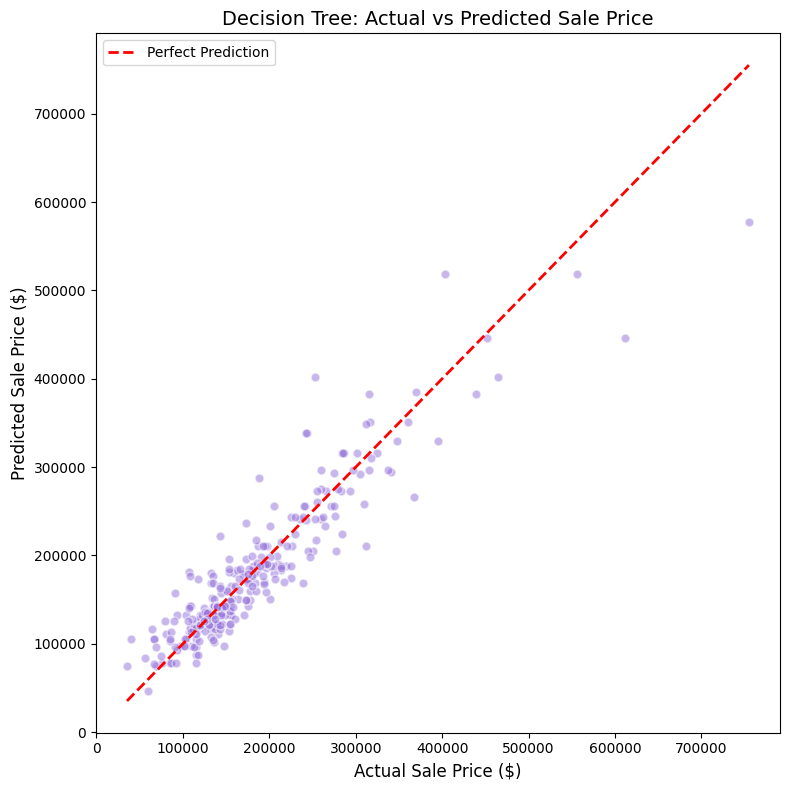

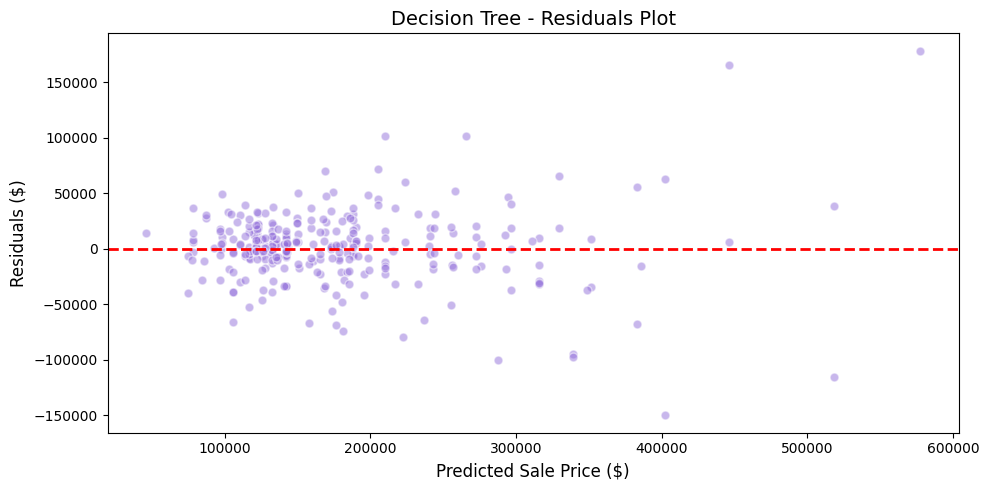

In [14]:
# --- Plot 1: Actual vs Predicted ---
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred_final, alpha=0.5, color='mediumpurple', edgecolors='white', s=40)
min_val = min(y_actual.min(), y_pred_final.min())
max_val = max(y_actual.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title('Decision Tree: Actual vs Predicted Sale Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('dt_actual_vs_predicted.png', dpi=150)
plt.show()

# --- Plot 2: Residuals ---
residuals = y_actual - y_pred_final
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_final, residuals, alpha=0.5, color='mediumpurple', edgecolors='white', s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sale Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Decision Tree - Residuals Plot', fontsize=14)
plt.tight_layout()
plt.savefig('dt_residuals.png', dpi=150)
plt.show()

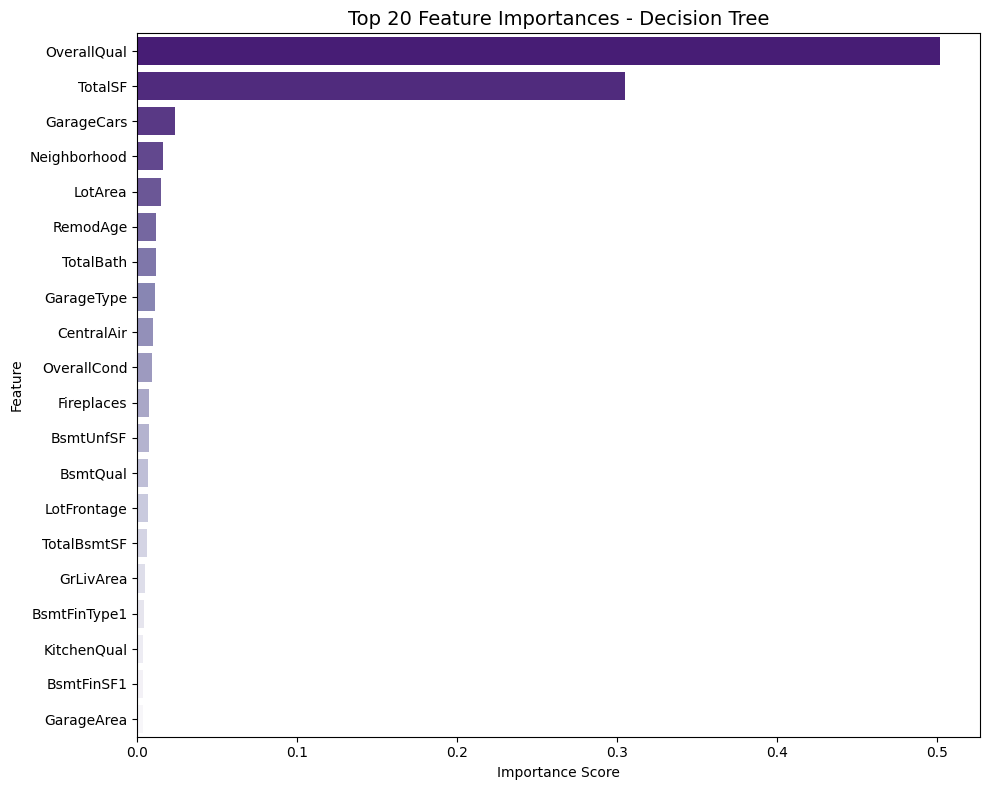

Top 5 Most Important Features:
     Feature  Importance
 OverallQual    0.501875
     TotalSF    0.305230
  GarageCars    0.023731
Neighborhood    0.016110
     LotArea    0.014670


In [15]:
importances = best_dt.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            hue='Feature', palette='Purples_r', legend=False)
plt.title('Top 20 Feature Importances - Decision Tree', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importances.png', dpi=150)
plt.show()

print("Top 5 Most Important Features:")
print(feat_imp_df.head(5).to_string(index=False))

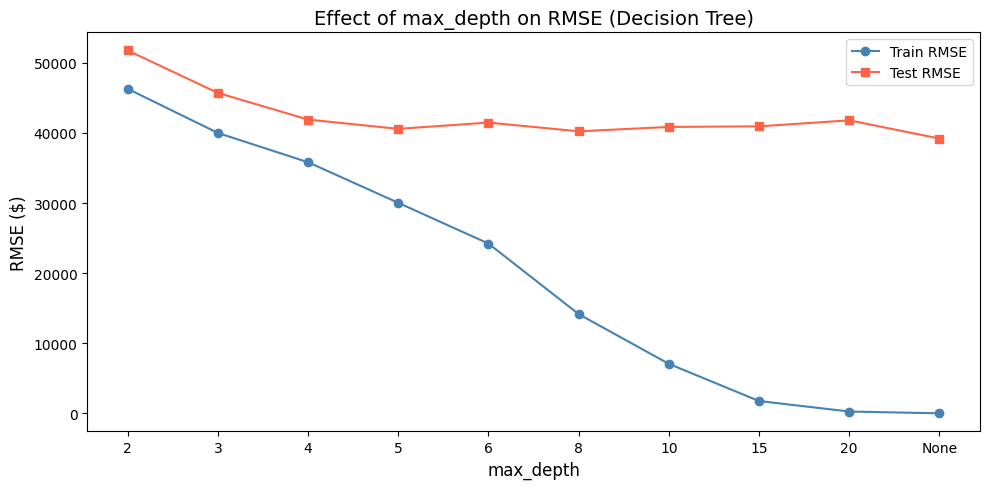

In [16]:
depths = [2, 3, 4, 5, 6, 8, 10, 15, 20, None]
train_rmse_list = []
test_rmse_list  = []

for d in depths:
    dt_temp = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_pred = np.expm1(dt_temp.predict(X_train))
    test_pred  = np.expm1(dt_temp.predict(X_test))
    train_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_train), train_pred)))
    test_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_test),  test_pred)))

depth_labels = [str(d) if d is not None else 'None' for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(depth_labels, train_rmse_list, marker='o', label='Train RMSE', color='steelblue')
plt.plot(depth_labels, test_rmse_list,  marker='s', label='Test RMSE',  color='tomato')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('RMSE ($)', fontsize=12)
plt.title('Effect of max_depth on RMSE (Decision Tree)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('dt_depth_vs_rmse.png', dpi=150)
plt.show()

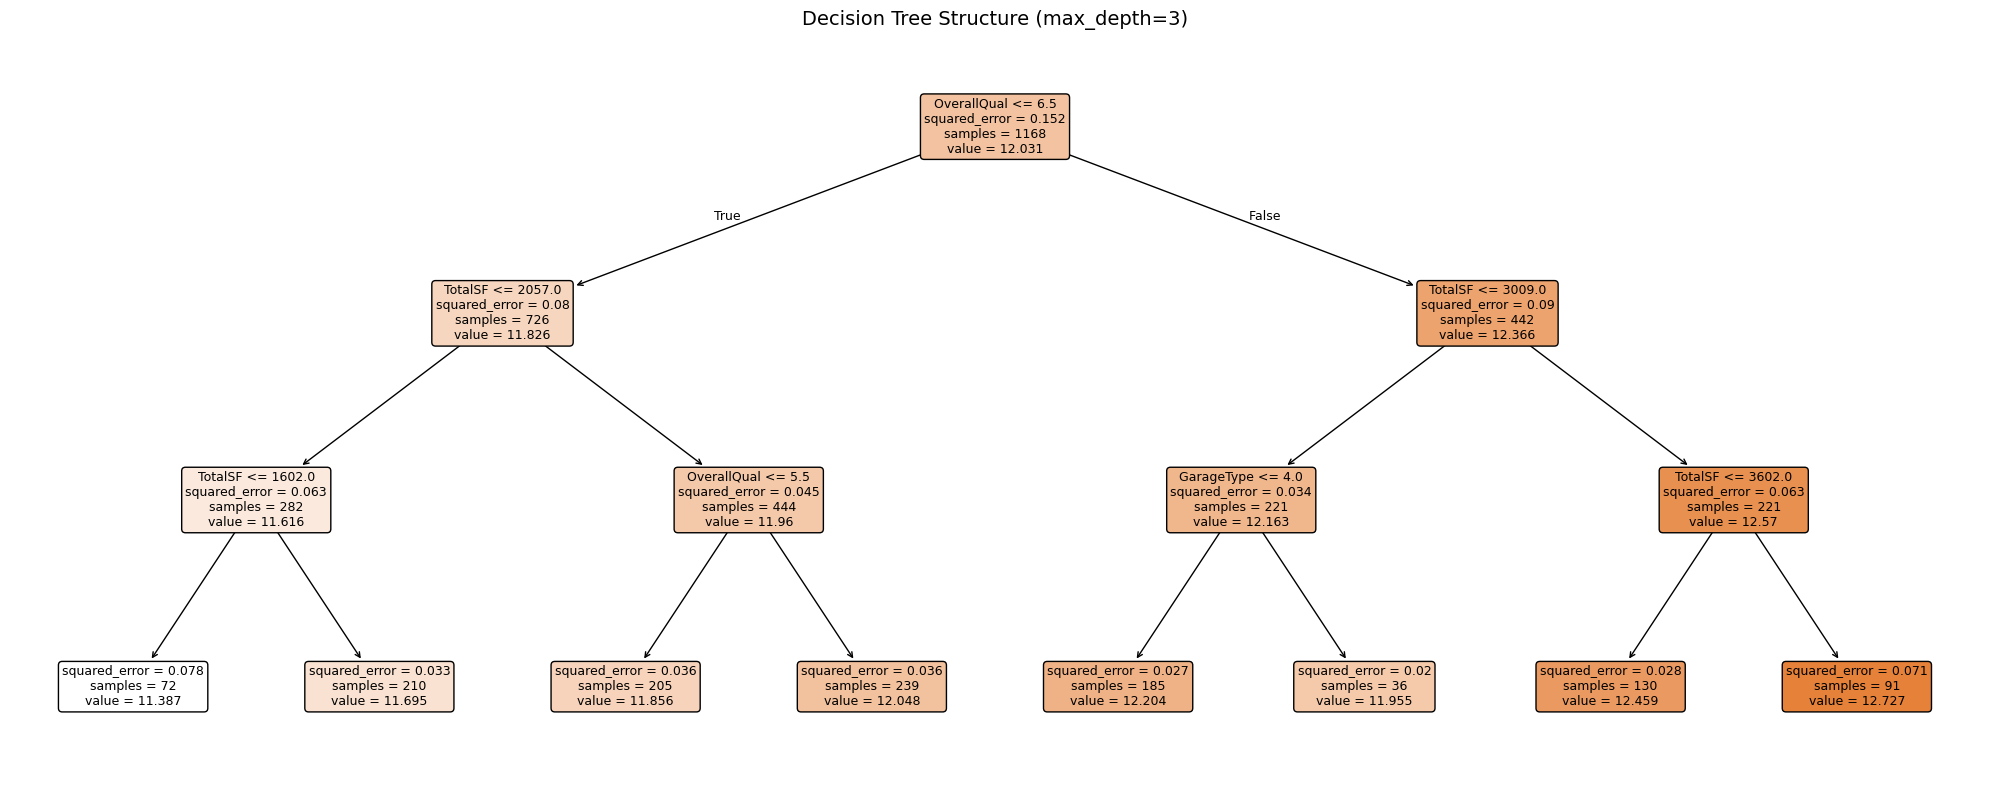

In [17]:
dt_visual = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_visual.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_visual, feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Structure (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.savefig('dt_tree_structure.png', dpi=150)
plt.show()

## 10. Summary of Results

In [18]:
y_pred_baseline_orig = np.expm1(dt_baseline.predict(X_test))
y_true_orig          = np.expm1(y_test)

summary = pd.DataFrame({
    'Model': ['Baseline DT (no limit)', 'Tuned DT (GridSearchCV)'],
    'MAE ($)': [
        f"{mean_absolute_error(y_true_orig, y_pred_baseline_orig):,.0f}",
        f"{mean_absolute_error(y_true_orig, y_pred_final):,.0f}"
    ],
    'RMSE ($)': [
        f"{np.sqrt(mean_squared_error(y_true_orig, y_pred_baseline_orig)):,.0f}",
        f"{np.sqrt(mean_squared_error(y_true_orig, y_pred_final)):,.0f}"
    ],
    'R2': [
        f"{r2_score(y_true_orig, y_pred_baseline_orig):.4f}",
        f"{r2_score(y_true_orig, y_pred_final):.4f}"
    ]
})

print("========== Final Results Summary ==========")
print(summary.to_string(index=False))

========== Final Results Summary ==========
                  Model MAE ($) RMSE ($)     R2
 Baseline DT (no limit)  25,148   39,204 0.7996
Tuned DT (GridSearchCV)  22,239   33,429 0.8543


In [19]:
import json, os

os.makedirs("../../results", exist_ok=True)

y_pred = y_pred_final
y_true = y_actual

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

results_dict = {
    "model": "decision_tree",
    "RMSE" : round(rmse, 2),
    "R2"   : round(r2,   4)
}

with open("../../results/decision_tree_results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to ../../results/decision_tree_results.json")
print(json.dumps(results_dict, indent=2))

Results saved to ../../results/decision_tree_results.json
{
  "model": "decision_tree",
  "RMSE": 33428.62,
  "R2": 0.8543
}
